# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Se usa para construir la ruta del experimento en tu carpeta personal de usuario dentro de databricks] ¿Qué debes hacer con esta variable email?
email = '202630597@alu.comillas.edu'  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [indica a mflow donde debe guardar y consultar los datos de los experimentros. al poner databricks le decimos que use el servidor de tracking de databricks en lugar de un servidor local o de otro proveedor, para que todo quede centralizado en el workspace] ¿Para qué sirve set_tracking_uri?
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [selecciona el experiemnto de mlflow en el que se agruparan todas las ejcuciones que hagamos a partir de ahora] ¿Qué hace set_experiment?
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/202630597@alu.comillas.edu/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: [Cargamos los datos de un archivo csv local ubicado en la carpeta "raw". este archivo contiene el UCI heart disease dataset] ¿De dónde cargamos los datos y qué contiene este archivo?
data = pd.read_csv('../data/raw/heart.csv')

print("=" * 70)
print("❤️  DATASET CARGADO: UCI HEART DISEASE")
print("=" * 70)
print(f"📊 Número de muestras: {len(data)}")
print(f"📈 Número de características: {len(data.columns) - 1}")  # -1 porque target no es característica
print(f"🎯 Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)")
print("=" * 70)

❤️  DATASET CARGADO: UCI HEART DISEASE
📊 Número de muestras: 303
📈 Número de características: 13
🎯 Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)


In [0]:
# TODO: [Nos muestra las primeras 5 filas del dataframe, permitiendo echar un primer vistazo rapido a la estructura real de los datos. es util porque no ayuda a detectar los problemas evidentes (columnas mal nombradas, valores extraños etc) antes de invertir tiempo en analisis mas profundos] ¿Qué nos muestra head() y por qué es útil?
print("🔍 Primeras 5 filas del dataset:\n")
data.head()

🔍 Primeras 5 filas del dataset:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: [info() resume la estructura tecnica del dataframe, el numero total de filas, el de columnas, el nombre de cada column, cuantos valores no nulos tiene y el tipo de dato de cada columna.] ¿Qué información nos da info() sobre el dataset?
print("ℹ️  Información general del dataset:\n")
data.info()

ℹ️  Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: [decribe() calcula estadisticas resumen para cada columna numerica, el numero de valores, la media, la desviacion estandar, el valor minimo y maximo y los percentiles. esto nos permite entender tapidamente el rango y la distribucion de cada variable clinica.] ¿Qué estadísticas nos proporciona describe()?
print("📊 Estadísticas descriptivas:\n")
data.describe()

📊 Estadísticas descriptivas:



,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [COn la edad media podemos ver que los pacientes de este dataset suelen tener una edad media de 54 años, lo cual es coherente con que las enfermedades cardiovasculares afectan principalmente a personas de mediana edad y mayores. luego en el rango de valroes de cada caracteristica podemos ver que las columnas tienen escalas muy distintas entre si. esta gran diferencia de escalas es importante porque algunos algoritmos son sensibles a ella. EN cuanto a los valores nulos, en la la version estandar y limpia de este dataset normalmente no hay valores nulos explicitos (NaN). Y pro ultimo las caracteristicas que pueden necesitar normalizacoin/escaclado, nos encontramos con variables con rangos amplios y unidades muy distintas, especialmente para modelos basados en gradiente como SGD, que son sencibles a la escala de las variables. en cambio, random forest es mas robusto a estas diferencias de sescala y no las necesita estrictamente.] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes 
- El rango de valores de cada característica
- La presencia de valores nulos
- Características que pueden necesitar normalización

In [0]:
# TODO: [Es importante porque el balance de clases en la variable objetivo condiciona tanto la eleccion de metricas de evaluacion como la estraregia de entrenamiento. si una clase es mucho mas frecuente que la otra, un modelo podria obtener una accuracy alta simplemetne prediciendo siempre la clase mayoritaria, sin haber aprendido realmente a distinguir los casos de enferemdad] ¿Por qué es importante analizar la distribución del target?
print("🎯 Distribución de la variable objetivo:\n")
target_counts = data.target.value_counts()
print(target_counts)
print(f"\nProporción:")
print(f"  - Sin enfermedad (0): {target_counts[0]/len(data)*100:.1f}%")
print(f"  - Con enfermedad (1): {target_counts[1]/len(data)*100:.1f}%")

# TODO: [Este calcilo obtiene el ratio entre la clase minoritaria y la maypritaria. Es importante porque el UCI heart disease dataset suele estar bastante equilibrado entre pacientes con y sin enfermedad, pero comprobarlo explicitamente evita asumirlo a ciegas. si resultara desbalanceado, tendriamos que ajustar el enfoque] ¿Está balanceado el dataset? ¿Por qué es importante?
balance_ratio = min(target_counts) / max(target_counts)
if balance_ratio > 0.8:
    print(f"\n✅ Dataset balanceado (ratio: {balance_ratio:.2f})")
else:
    print(f"\n⚠️  Dataset desbalanceado (ratio: {balance_ratio:.2f})")

🎯 Distribución de la variable objetivo:

target
1    165
0    138
Name: count, dtype: int64

Proporción:
  - Sin enfermedad (0): 45.5%
  - Con enfermedad (1): 54.5%

✅ Dataset balanceado (ratio: 0.84)


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

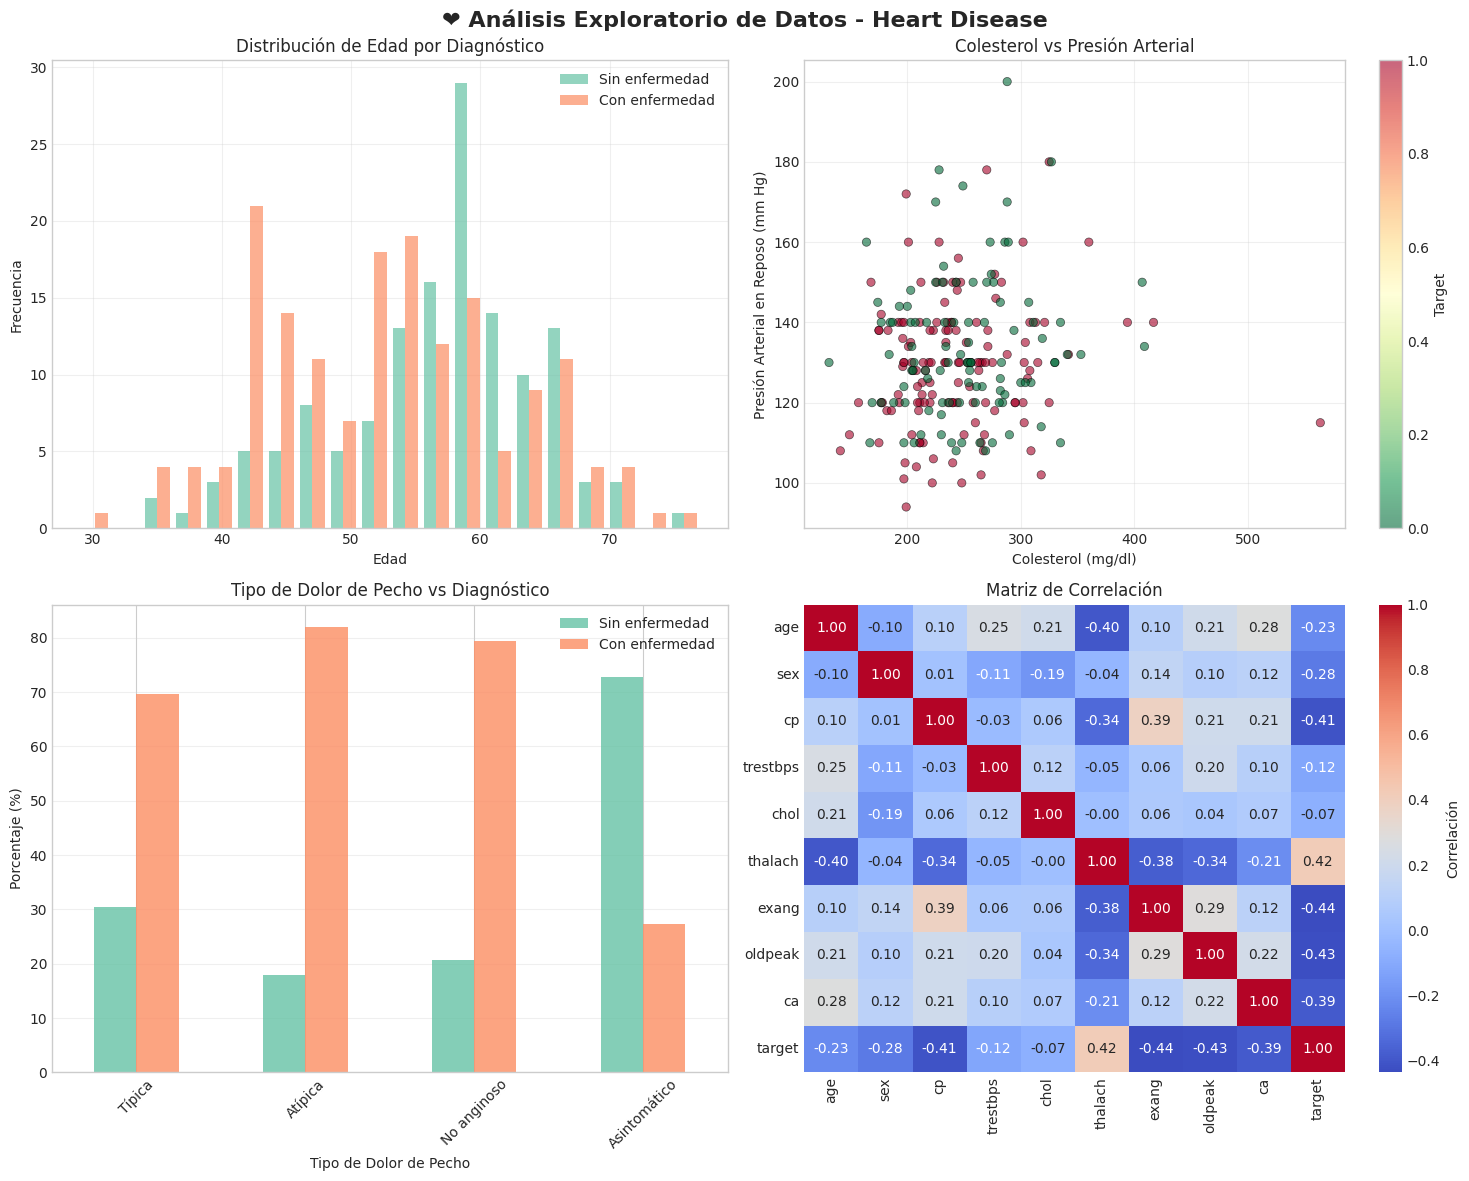

✅ Visualizaciones generadas

Patrones observados:
Edad: los pacientes con enfermedad tienden a concentrarse en edades medias-altas, aunque la edad por si sola no separa perfectamente ambos grupos, hay solapamiento considerable.
Colesterol vs presion arterial: no suele verse una separacion clara de colores en este scatter, ambas variables por si solas son predictores debiles, lo que sugiere que el diagnostico depende de la combinacion de varias caracteristicas, no de una sola.
Tipo de dolor de pecho: suele mostrar una de las relaciones mas fuertes con el target, curiosamente, el dolor asintomatico se asocia con mayor proporcion de enfermedad, mientras que la angina tipica se asocia con menor proporcion, algo contraintuitivo pero consistente con la literatura medica.
Matriz de correlacion: variables como cp, thalach y exang suelen mostrar correlaciones mas fuertes con target que variables como chol o trestbps, que aparecen mas debilmente correlacionadas de forma lineal con la enfermedad.

In [0]:
# TODO: [Estas visualizaciones nos permiten explorar, de forma grafica, como se relacionan las distintas variables clinicas con la presencia o ausencia de enfermedad cardiaca. mientras que las tablas de estadisticas nos dan numeros asilados, los graficos no ayudan a detectar oatrones, agrupaciones y relaciones entre variables que serian dificiles de ver solo con numeros] ¿Qué podemos aprender de las visualizaciones?

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('❤️ Análisis Exploratorio de Datos - Heart Disease', fontsize=16, fontweight='bold')

# Gráfico 1: Distribución de edad por target
axes[0, 0].hist([data[data.target==0]['age'], data[data.target==1]['age']], 
                bins=20, label=['Sin enfermedad', 'Con enfermedad'], alpha=0.7)
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Edad por Diagnóstico')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Colesterol vs Presión Arterial
scatter = axes[0, 1].scatter(data['chol'], data['trestbps'], c=data['target'], 
                             alpha=0.6, cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Colesterol (mg/dl)')
axes[0, 1].set_ylabel('Presión Arterial en Reposo (mm Hg)')
axes[0, 1].set_title('Colesterol vs Presión Arterial')
plt.colorbar(scatter, ax=axes[0, 1], label='Target')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tipo de dolor de pecho por diagnóstico
cp_target = pd.crosstab(data['cp'], data['target'], normalize='index') * 100
cp_target.plot(kind='bar', ax=axes[1, 0], alpha=0.8)
axes[1, 0].set_xlabel('Tipo de Dolor de Pecho')
axes[1, 0].set_ylabel('Porcentaje (%)')
axes[1, 0].set_title('Tipo de Dolor de Pecho vs Diagnóstico')
axes[1, 0].legend(['Sin enfermedad', 'Con enfermedad'])
axes[1, 0].set_xticklabels(['Típica', 'Atípica', 'No anginoso', 'Asintomático'], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Gráfico 4: Matriz de correlación (top 10 características)
top_features = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'thalach', 'exang', 'oldpeak', 'ca', 'target'
]

# Hacemos una copia para no modificar el dataset original
corr_data = data[top_features].copy()

# Convertimos las variables categóricas a números
for column in corr_data.select_dtypes(include='object').columns:
    corr_data[column] = corr_data[column].astype('category').cat.codes

corr_matrix = corr_data.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[1, 1],
    cbar_kws={'label': 'Correlación'}
)

axes[1, 1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("""
Patrones observados:
Edad: los pacientes con enfermedad tienden a concentrarse en edades medias-altas, aunque la edad por si sola no separa perfectamente ambos grupos, hay solapamiento considerable.
Colesterol vs presion arterial: no suele verse una separacion clara de colores en este scatter, ambas variables por si solas son predictores debiles, lo que sugiere que el diagnostico depende de la combinacion de varias caracteristicas, no de una sola.
Tipo de dolor de pecho: suele mostrar una de las relaciones mas fuertes con el target, curiosamente, el dolor asintomatico se asocia con mayor proporcion de enfermedad, mientras que la angina tipica se asocia con menor proporcion, algo contraintuitivo pero consistente con la literatura medica.
Matriz de correlacion: variables como cp, thalach y exang suelen mostrar correlaciones mas fuertes con target que variables como chol o trestbps, que aparecen mas debilmente correlacionadas de forma lineal con la enfermedad.
""")

## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: [Dividimos los datos en dos conjuntos separados para poder evaluar el modelo de forma honesta: el conjunto de entrenamiento se usa para que el modelo aprenda los patrones de los datos y el cojunto de prueba se reserva y NO se toca durante el entrenamietno, para usarlo despues como una simulacion de datos nuvos y medir el rendimiento real del modelo.] ¿Por qué dividimos en train y test? ¿Qué es test_size y random_state?
train_set, test_set = train_test_split(data, test_size=0.2, random_state=5)

print("=" * 70)
print("🔀 DIVISIÓN DE DATOS")
print("=" * 70)
print(f"📊 Total de muestras: {len(data)}")
print(f"📚 Conjunto de entrenamiento: {len(train_set)} ({len(train_set)/len(data)*100:.1f}%)")
print(f"🧪 Conjunto de prueba: {len(test_set)} ({len(test_set)/len(data)*100:.1f}%)")
print("=" * 70)
print("✅ Datos divididos correctamente")

🔀 DIVISIÓN DE DATOS
📊 Total de muestras: 303
📚 Conjunto de entrenamiento: 242 (79.9%)
🧪 Conjunto de prueba: 61 (20.1%)
✅ Datos divididos correctamente


📊 Generando histogramas de distribuciones...



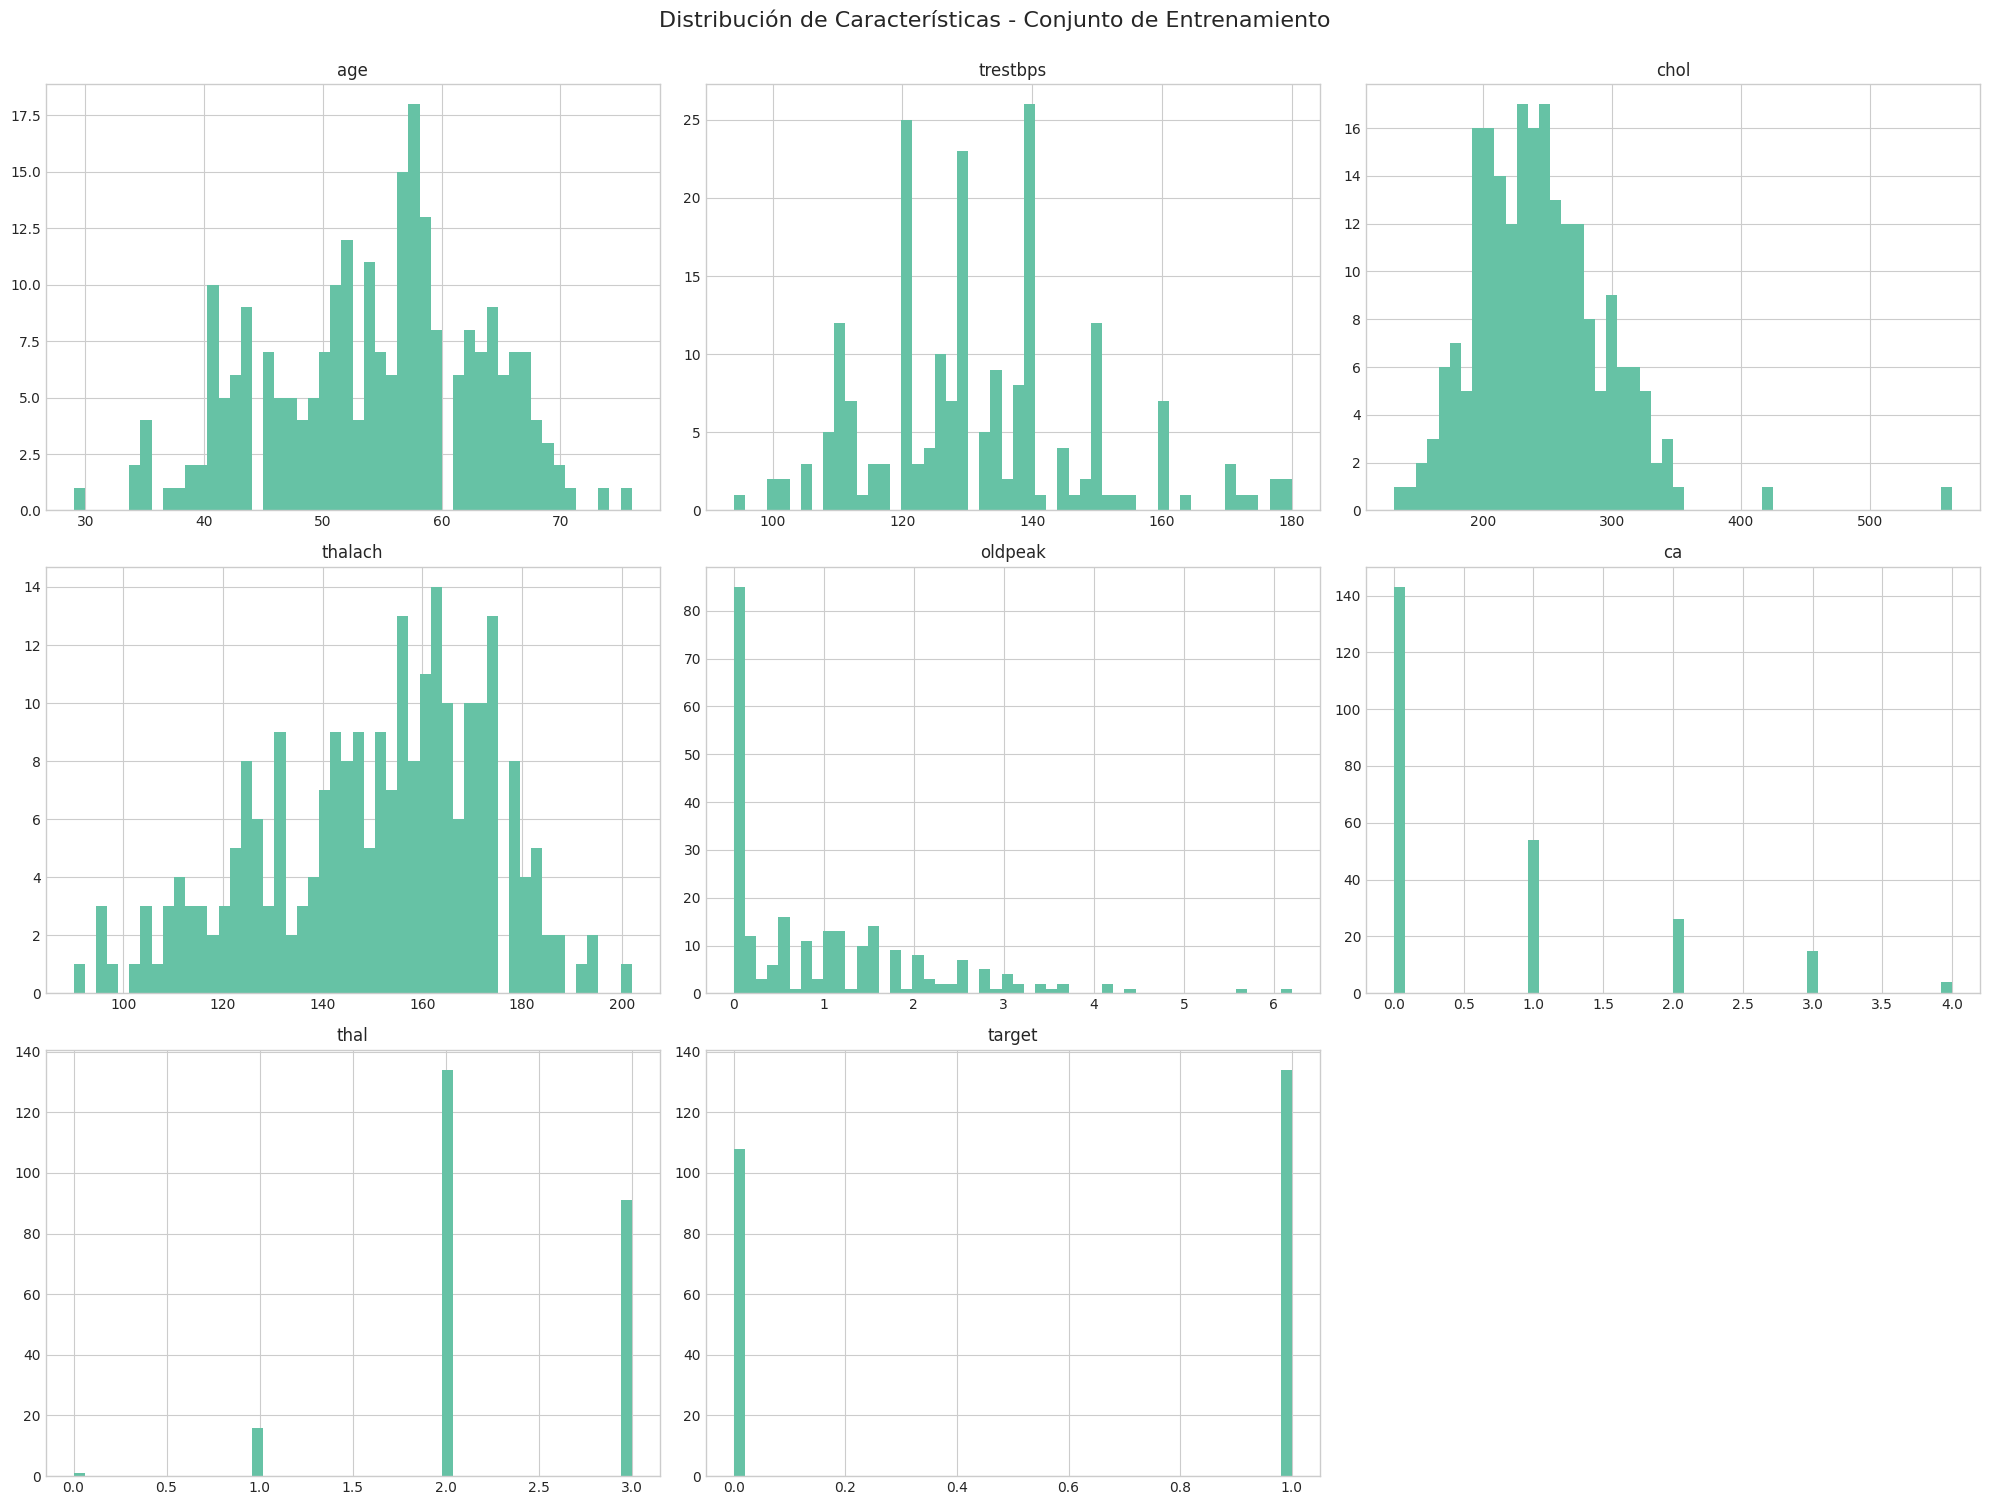

💡 TODO: [Las que más se diferencian son chol, trestbps, thalach y age, porque tienen rangos y formas de distribución bastante distintas. Por ejemplo, chol tiene valores mucho más altos y dispersos, mientras que age está más concentrada en un rango menor. También hay variables categóricas que toman pocos valores concretos y por eso sus histogramas tienen una forma muy diferente.] ¿Qué características tienen distribuciones muy diferentes?


In [0]:
# TODO: [los histrogramas muestan como se distribuyenn sus valores, en que rangos concentran la mayoria de los pacientes, si la distribucion es simetrica o sesgada, y si ecisten valores activos atipivos o escalas muy distintas entre variables. son importantes porque nos ayudan a decidir el preprocesado necesario antes de entrenar] ¿Qué nos muestran los histogramas y por qué son importantes?
print("📊 Generando histogramas de distribuciones...\n")
train_set.hist(bins=50, figsize=(20, 15))
plt.suptitle('Distribución de Características - Conjunto de Entrenamiento', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("💡 TODO: [Las que más se diferencian son chol, trestbps, thalach y age, porque tienen rangos y formas de distribución bastante distintas. Por ejemplo, chol tiene valores mucho más altos y dispersos, mientras que age está más concentrada en un rango menor. También hay variables categóricas que toman pocos valores concretos y por eso sus histogramas tienen una forma muy diferente.] ¿Qué características tienen distribuciones muy diferentes?")

### 📏 Observación Importante: Escalas Diferentes

**TODO: [es un problema porque muchos algorimos de machine learnign interpretan la magnitud numerica de cada variable como una señal de importancia. si el colesterol va de 126  564 y la edad de 29 a 77, el modelo podria darle mucho mas peso al colesterol simplemente porque sus numeros son mas grandes, no porque sea realmente mas relvante para predecir la enfermedad. esto distrosiona el aprendizaje y ahce que el modelo converja mas lento o llegue a una solucion suboptima] ¿Por qué es un problema que las características tengan escalas diferentes?**

Las características tienen diferentes escalas:
- **age**: 29-77 años
- **trestbps**: 94-200 mm Hg
- **chol**: 126-564 mg/dl
- **thalach**: 71-202

**Solución**: Aplicaremos **Standard Scaling** (estandarización) para que todas las características tengan:
- Media = 0
- Desviación estándar = 1

**TODO: [ayuda porque al poner todas las variables en lamisma escala, ninguna carctaeristica domina el aprendizaje solo por tener numeros mas grandes, esto permmite que algoritmos como SGD converjan mas rapido y de forma mas estable durante el entrenamiento, yq ue modelos basados en distancias calculen distancias de forma justa entre todas las varibales.modlos basados en arboles, son mas robustos a esto y no lo necesitan estrictamente, pero aplicar el escalado no les perjudica y mantiene el pipeline consistente apra comparar mabos algoritmos] ¿Por qué esto ayuda a los modelos de Machine Learning?**

## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: [las variables categoricas son aquellas que representan clases o grupos discrteos, auqnue esten codificados como numeros, indetifican una categoria, y las numericas representan magnitudes continuas o cuasi-continuas donde l valor numerico tiene un significado real de cantidad.] ¿Cuáles son las variables categóricas y cuáles numéricas?
cat_attr = ["sex", "cp", "fbs", "restecg", "exang", "slope"]
num_attr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal"]

print("📋 Clasificación de variables:")
print(f"   📊 Numéricas ({len(num_attr)}): {num_attr}")
print(f"   🏷️  Categóricas ({len(cat_attr)}): {cat_attr}")

# TODO: [Simleimputer rellena automaticamente los valores nulos de cad acolumna numerica con un valor calculasdo a partit de los datos dsiponibles. usamos la mediana en lugar de l amedia porque la mediana es mas robusta  ante valores atipicos.] ¿Qué hace SimpleImputer y por qué usamos la mediana?
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Rellenar valores nulos
    ("std_scaler", StandardScaler())                # Estandarizar
])

# TODO: [ColumnTransformer permite aplicar transformacioens distintas a distintos subconjutnos de columnas detr de un mismo pipeline. lo necesitamos porque numericamente seria mas porpenso a errores y menos reproducible que dejar que columntranssformer lo gestiones de forma automatica y consistente, tanto en train como en test] ¿Qué es ColumnTransformer y por qué lo necesitamos?
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attr),      # Pipeline para numéricas
    ("cat", OneHotEncoder(), cat_attr)    # One-Hot Encoding para categóricas
])

print("\n✅ Pipeline de preprocesamiento creado")
print("\n💡 El pipeline:")
print("   1. Rellena valores nulos con la mediana (numéricas)")
print("   2. Estandariza variables numéricas (media=0, std=1)")
print("   3. Aplica One-Hot Encoding a variables categóricas")
print("\n💡 TODO: [one hot encoding convierte cada catergoria en una clumna binaria (0 a 1) independiente, evitando que el modelo interprete numeros como cp o restecg como si tuvieran un orden o magnitud real entre categorias] ¿Por qué One-Hot Encoding para categóricas? Se usa One-Hot Encoding porque convierte cada categoría en una columna binaria independiente de 0 y 1. Así evitamos que el modelo interprete valores como cp o restecg como si tuvieran un orden o una diferencia numérica real entre sus categorías.")

📋 Clasificación de variables:
   📊 Numéricas (7): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']
   🏷️  Categóricas (6): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

✅ Pipeline de preprocesamiento creado

💡 El pipeline:
   1. Rellena valores nulos con la mediana (numéricas)
   2. Estandariza variables numéricas (media=0, std=1)
   3. Aplica One-Hot Encoding a variables categóricas

💡 TODO: [one hot encoding convierte cada catergoria en una clumna binaria (0 a 1) independiente, evitando que el modelo interprete numeros como cp o restecg como si tuvieran un orden o magnitud real entre categorias] ¿Por qué One-Hot Encoding para categóricas? Se usa One-Hot Encoding porque convierte cada categoría en una columna binaria independiente de 0 y 1. Así evitamos que el modelo interprete valores como cp o restecg como si tuvieran un orden o una diferencia numérica real entre sus categorías.


## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: [separamos c e y porque skixit learn necesita distinguir que es lo que el modelo usa para predecir y que es lo que debe predeci. el traget (y) quedara dentro de x, el modelo haria data leakage, usando la respuesta como su fiera una caracterisitca mas.] ¿Por qué separamos X (características) de y (target)?
x_train = train_set.drop("target", axis=1)  # Características
y_train = train_set.target                   # Variable objetivo

print("=" * 70)
print("🎯 SEPARACIÓN DE CARACTERÍSTICAS Y TARGET")
print("=" * 70)
print(f"X_train shape: {x_train.shape} (características)")
print(f"y_train shape: {y_train.shape} (target)")
print("=" * 70)

🎯 SEPARACIÓN DE CARACTERÍSTICAS Y TARGET
X_train shape: (242, 13) (características)
y_train shape: (242,) (target)


In [0]:
# TODO: [fit transform aprende los parametros con los datos de train y los aplicas. transfroma solo apica parametros ya aprendidos, sin recalcularlos.] ¿Qué diferencia hay entre fit_transform y transform?
x_train_pr = full_pipeline.fit_transform(x_train)

print("🔧 Pipeline aplicado al conjunto de entrenamiento")
print(f"   Shape original: {x_train.shape}")
print(f"   Shape procesado: {x_train_pr.shape}")
print(f"\n💡 TODO: [aumentan porque one hot encoding convierte cada variable categorica en varias columans binarias] ¿Por qué cambió el número de columnas? El número de columnas aumenta porque el One-Hot Encoding transforma cada variable categórica en varias columnas binarias, una por cada categoría posible. Por eso se pasa de 13 columnas originales a 23 después del preprocesado.")

2026/10/03 17:43:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o626.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

🔧 Pipeline aplicado al conjunto de entrenamiento
   Shape original: (242, 13)
   Shape procesado: (242, 23)

💡 TODO: [aumentan porque one hot encoding convierte cada variable categorica en varias columans binarias] ¿Por qué cambió el número de columnas? El número de columnas aumenta porque el One-Hot Encoding transforma cada variable categórica en varias columnas binarias, una por cada categoría posible. Por eso se pasa de 13 columnas originales a 23 después del preprocesado.


## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [SGD (Stochastic Gradient Descent) es un método de optimización que se utiliza para entrenar modelos de aprendizaje automático. Va ajustando poco a poco los parámetros del modelo para reducir el error. A diferencia del descenso de gradiente normal, SGD actualiza el modelo usando una muestra cada vez, por lo que suele ser más rápido cuando tenemos muchos datos.] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# Activar autolog de MLflow
mlflow.sklearn.autolog()

# Iniciar experimento con MLflow
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
    
    print("=" * 70)
    print("🚀 ENTRENANDO MODELO BASELINE: SGD CLASSIFIER")
    print("=" * 70)
    
    # TODO: [random state fija la semilla aleatoria del modelo, para que los reusltados sean reproducibles entre ejcuciones] ¿Qué es random_state y por qué lo usamos?
    sgd_clf = SGDClassifier(random_state=42)
    
    # TODO: [divide los datos en 3 partes: entrena 3 veces usando 2 como train y 1como test cada vez para obtener una estimacion mas robustaa del rendimiento ] ¿Qué es validación cruzada con 3 folds?
    print("\n🔄 Realizando validación cruzada (3-fold)...")
    scores = cross_val_score(sgd_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    
    print(f"\n📊 Accuracy por fold:")
    for i, score in enumerate(scores, 1):
        print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")
    
    print(f"\n📈 Accuracy promedio: {scores.mean():.4f} ± {scores.std():.4f}")
    
    # Registrar métrica en MLflow
    mlflow.log_metric("cv_accuracy_mean", scores.mean())
    mlflow.log_metric("cv_accuracy_std", scores.std())
    
    print("\n✅ Modelo SGD entrenado con validación cruzada")
    print("=" * 70)

2026/10/03 17:38:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o11.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

🚀 ENTRENANDO MODELO BASELINE: SGD CLASSIFIER

🔄 Realizando validación cruzada (3-fold)...


🔗 View Logged Model at: https://dbc-af132e6b-fd3c.cloud.databricks.com/ml/experiments/4210421694061144/models/m-f639773b3af94beebfc1587d666cd3c4?o=7474655870086436
2026/10/03 17:39:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o44.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.Instrument


📊 Accuracy por fold:
   Fold 1: 0.7407 (74.07%)
   Fold 2: 0.7531 (75.31%)
   Fold 3: 0.7875 (78.75%)

📈 Accuracy promedio: 0.7604 ± 0.0198

✅ Modelo SGD entrenado con validación cruzada


### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: [cross val predcit entrena folds distintos y predice cada muestra solo cuando estaba en el fold de test, evitando que el modelo prediga datos que ya vio en entrenamientoÇ] ¿Por qué usamos cross_val_predict en lugar de solo predecir?
print("🔮 Obteniendo predicciones con validación cruzada...")
preds = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=3)
print(f"✅ {len(preds)} predicciones generadas")

2026/10/03 17:39:29 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o162.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

🔮 Obteniendo predicciones con validación cruzada...


2026/10/03 17:39:29 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o171.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

✅ 242 predicciones generadas


📊 Generando matriz de confusión...



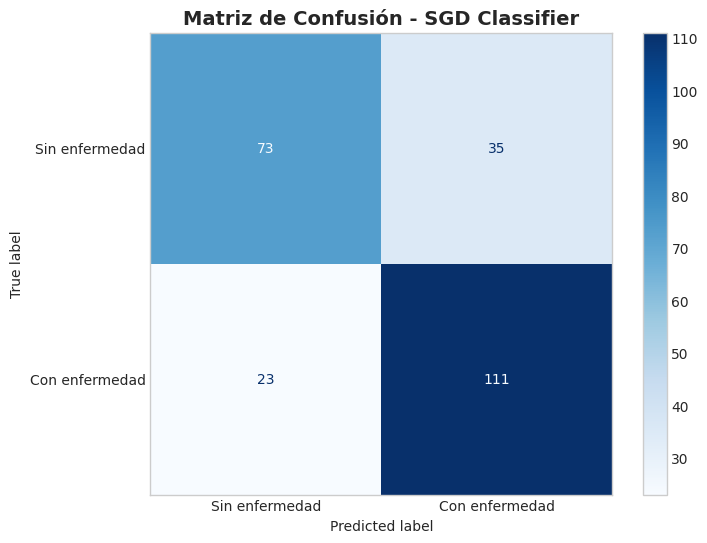


📋 Interpretación de la matriz:
   TN (Verdaderos Negativos): 73 - Correctamente identificados como sanos
   FP (Falsos Positivos): 35 - Sanos clasificados como enfermos
   FN (Falsos Negativos): 23 - Enfermos clasificados como sanos ⚠️
   TP (Verdaderos Positivos): 111 - Correctamente identificados como enfermos

💡 TODO: [El falso negativo, un enfermo real que el modelo clasifica como sano no recibe tratamiento a tiempo, poniendo su vida en riesgo. Por eso en medicina se prioriza recall sobre precision] ¿Qué tipo de error es más grave en medicina?


In [0]:
# TODO: [la matrix de confusion muestra, en una tabla, como se comparan las predicciones del modelo con la realida] ¿Qué nos muestra la matriz de confusión?
print("📊 Generando matriz de confusión...\n")

cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - SGD Classifier', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

print(f"\n📋 Interpretación de la matriz:")
print(f"   TN (Verdaderos Negativos): {cm[0,0]} - Correctamente identificados como sanos")
print(f"   FP (Falsos Positivos): {cm[0,1]} - Sanos clasificados como enfermos")
print(f"   FN (Falsos Negativos): {cm[1,0]} - Enfermos clasificados como sanos ⚠️")
print(f"   TP (Verdaderos Positivos): {cm[1,1]} - Correctamente identificados como enfermos")
print(f"\n💡 TODO: [El falso negativo, un enfermo real que el modelo clasifica como sano no recibe tratamiento a tiempo, poniendo su vida en riesgo. Por eso en medicina se prioriza recall sobre precision] ¿Qué tipo de error es más grave en medicina?")

In [0]:
# TODO: [PRECISION: proporcion de predichos como enfermeos que realmente lo estan. RECALL: proporcion de enfermos reales que el modelo detecto. F1: media armoncia entre precision y recall. ROC-AUC: capacidad del model de distinguir entre casles en distintos umbrales] ¿Qué mide cada una de estas métricas?
print("=" * 70)
print("📊 MÉTRICAS DEL MODELO SGD")
print("=" * 70)

precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

print(f"🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   → De los que predije como enfermos, el {precision*100:.1f}% realmente lo están")
print(f"\n❤️  Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"   → Detecté el {recall*100:.1f}% de todos los enfermos reales")
print(f"\n⚖️  F1 Score: {f1:.4f}")
print(f"   → Balance entre precision y recall")
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")
print(f"   → Capacidad de discriminación del modelo")
print("=" * 70)

print("\n💡 TODO: [Recall porque un falso negativo es mucho mas peligroso que un falso positivo] ¿Qué métrica es más importante en medicina y por qué? En medicina, muchas veces una de las métricas más importantes es el recall, porque indica cuántos pacientes que realmente tienen la enfermedad somos capaces de detectar. Un falso negativo puede ser más peligroso que un falso positivo, ya que supondría no detectar a un paciente enfermo.") 

📊 MÉTRICAS DEL MODELO SGD
🎯 Precision: 0.7603 (76.03%)
   → De los que predije como enfermos, el 76.0% realmente lo están

❤️  Recall: 0.8284 (82.84%)
   → Detecté el 82.8% de todos los enfermos reales

⚖️  F1 Score: 0.7929
   → Balance entre precision y recall

📈 ROC-AUC Score: 0.7521
   → Capacidad de discriminación del modelo

💡 TODO: [Recall porque un falso negativo es mucho mas peligroso que un falso positivo] ¿Qué métrica es más importante en medicina y por qué? En medicina, muchas veces una de las métricas más importantes es el recall, porque indica cuántos pacientes que realmente tienen la enfermedad somos capaces de detectar. Un falso negativo puede ser más peligroso que un falso positivo, ya que supondría no detectar a un paciente enfermo.


### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Random Forest es un modelo que combina muchos árboles de decisión. Cada árbol hace su propia predicción y al final se combinan los resultados para obtener la respuesta final. Suele funcionar mejor que un modelo simple porque al usar varios árboles se reducen los errores de un único árbol y el modelo suele generalizar mejor con datos nuevos.] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# Continuar con MLflow (nuevo run para Random Forest)
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    
    print("=" * 70)
    print("🚀 ENTRENANDO MODELO: RANDOM FOREST CLASSIFIER")
    print("=" * 70)
    
    # TODO: [n_estimators, max_depth. min_samples_split,
    # min_samples_leaf, max_features, class_weight] ¿Qué hiperparámetros podríamos ajustar en Random Forest?
    rf_clf = RandomForestClassifier(random_state=42)
    
    # TODO: [Repetimos validaicon cruzada porque cada modelo necesita su propia evaluacion robusta, para poder comparar SGD vs RANDOM FROREST de forma justa] ¿Por qué volvemos a hacer validación cruzada?
    print("\n🔄 Realizando validación cruzada (3-fold)...")
    rf_scores = cross_val_score(rf_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    
    print(f"\n📊 Accuracy por fold:")
    for i, score in enumerate(rf_scores, 1):
        print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")
    
    print(f"\n📈 Accuracy promedio: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
    
    # Obtener predicciones
    rf_preds = cross_val_predict(rf_clf, x_train_pr, y_train, cv=3)
    
    # Registrar en MLflow
    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())
    mlflow.log_metric("cv_accuracy_std", rf_scores.std())
    
    print("\n✅ Modelo Random Forest entrenado")
    print("=" * 70)

2026/10/03 17:40:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o321.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

🚀 ENTRENANDO MODELO: RANDOM FOREST CLASSIFIER

🔄 Realizando validación cruzada (3-fold)...


2026/10/03 17:40:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o340.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente


📊 Accuracy por fold:
   Fold 1: 0.8025 (80.25%)
   Fold 2: 0.7778 (77.78%)
   Fold 3: 0.8000 (80.00%)

📈 Accuracy promedio: 0.7934 ± 0.0111


2026/10/03 17:40:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o483.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente


✅ Modelo Random Forest entrenado


📊 Matriz de Confusión - Random Forest



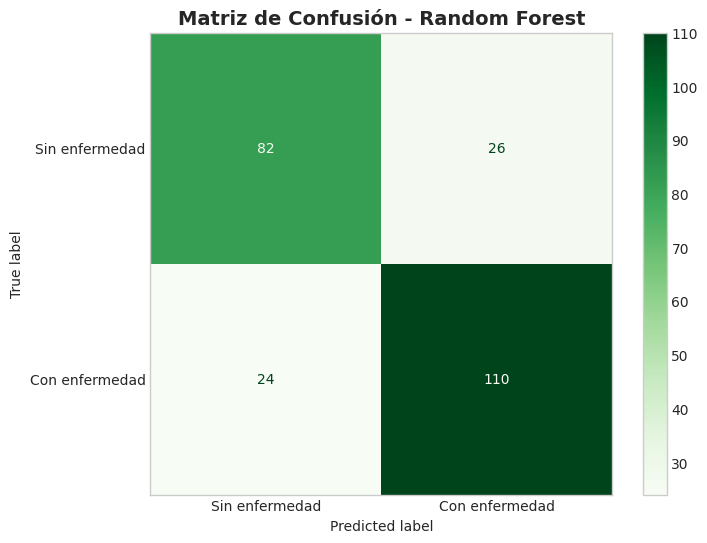


📋 Interpretación:
   TN: 82 | FP: 26
   FN: 24 | TP: 110

💡 TODO: [COmpara los valoraes FN y FP de ambas matrices. normalmente random forest reduce los falsos negativos frente a SGD, lo cual es la mejora mas relevante en un contexto medico.] ¿Mejoró respecto a SGD? ¿En qué?Sí, Random Forest mejora respecto a SGD, sobre todo porque consigue reducir los falsos negativos, es decir, detecta mejor a los pacientes que realmente tienen la enfermedad. En medicina esta mejora es especialmente importante, porque un falso negativo significa clasificar como sano a un paciente que en realidad está enfermo.


In [0]:
# TODO: [Radnom forest suele superar a SGD porque captura relaciones no lineales entre variables, mientras que SGD ajusta un modelo lineal mas simple] ¿Esperamos que la matriz de confusión sea mejor? ¿Por qué?
print("📊 Matriz de Confusión - Random Forest\n")

cm_rf = confusion_matrix(y_train, rf_preds)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(ax=ax, cmap='Greens')
plt.title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

print(f"\n📋 Interpretación:")
print(f"   TN: {cm_rf[0,0]} | FP: {cm_rf[0,1]}")
print(f"   FN: {cm_rf[1,0]} | TP: {cm_rf[1,1]}")
print(f"\n💡 TODO: [COmpara los valoraes FN y FP de ambas matrices. normalmente random forest reduce los falsos negativos frente a SGD, lo cual es la mejora mas relevante en un contexto medico.] ¿Mejoró respecto a SGD? ¿En qué?Sí, Random Forest mejora respecto a SGD, sobre todo porque consigue reducir los falsos negativos, es decir, detecta mejor a los pacientes que realmente tienen la enfermedad. En medicina esta mejora es especialmente importante, porque un falso negativo significa clasificar como sano a un paciente que en realidad está enfermo.")

In [0]:
# TODO: [comparamos viendo la columna diferencia. si es positiva, random forest mejora esa metrica respecto a SGD] ¿Cómo se comparan estas métricas con las de SGD?
print("=" * 70)
print("📊 MÉTRICAS DEL MODELO RANDOM FOREST")
print("=" * 70)

rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)

print(f"🎯 Precision: {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"❤️  Recall: {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"⚖️  F1 Score: {rf_f1:.4f}")
print(f"📈 ROC-AUC Score: {rf_roc_auc:.4f}")
print("=" * 70)

# Comparación con SGD
print("\n📊 COMPARACIÓN SGD vs RANDOM FOREST")
print("=" * 70)
comparison = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SGD': [precision, recall, f1, roc_auc],
    'Random Forest': [rf_precision, rf_recall, rf_f1, rf_roc_auc],
    'Diferencia': [
        rf_precision - precision,
        rf_recall - recall,
        rf_f1 - f1,
        rf_roc_auc - roc_auc
    ]
})
print(comparison.to_string(index=False))
print("=" * 70)

print("\n💡 TODO: [el modelo con mayor recall y roc-auc suele ser preferible en medicina, ya que random forest generalmente captura mejor relaciones no lineales entre las variables clinicas que un modelo lineal como SGD] ¿Qué modelo funciona mejor y por qué?")

📊 MÉTRICAS DEL MODELO RANDOM FOREST
🎯 Precision: 0.8088 (80.88%)
❤️  Recall: 0.8209 (82.09%)
⚖️  F1 Score: 0.8148
📈 ROC-AUC Score: 0.7901

📊 COMPARACIÓN SGD vs RANDOM FOREST
  Métrica      SGD  Random Forest  Diferencia
Precision 0.760274       0.808824    0.048550
   Recall 0.828358       0.820896   -0.007463
 F1-Score 0.792857       0.814815    0.021958
  ROC-AUC 0.752142       0.790077    0.037935

💡 TODO: [el modelo con mayor recall y roc-auc suele ser preferible en medicina, ya que random forest generalmente captura mejor relaciones no lineales entre las variables clinicas que un modelo lineal como SGD] ¿Qué modelo funciona mejor y por qué?


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: [Antes usabamos cross_val:score/predict para evaluar de forma robusta sin usar todos los datos a la vez. ahora que ya elegimos el modelo, lo entrenamos con el 100% del train para que aprenda de todos los patrones disponibles antes de evaluarlo con el conjunto de test. ] ¿Por qué ahora entrenamos con todos los datos de train?
print("🎯 Entrenamiento final con todo el conjunto de entrenamiento\n")

forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_train_pr, y_train)

print("✅ Modelo Random Forest entrenado con", len(x_train_pr), "muestras")
print("📊 El modelo ahora tiene más datos para aprender patrones")

2026/09/16 10:19:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o628.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

🎯 Entrenamiento final con todo el conjunto de entrenamiento



2026/09/16 10:19:07 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a4f7b90a7dcf4c9ab3c74c2623fa1aca', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/16 10:19:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o637.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instru

✅ Modelo Random Forest entrenado con 242 muestras
📊 El modelo ahora tiene más datos para aprender patrones


In [0]:
# TODO: [separamos c e y de test igual que en train, para poder pasar x_test por el mismo pipeline y comparar predicciones con y_test] ¿Por qué preparamos los datos de test de la misma manera?
x_test = test_set.drop("target", axis=1)
y_test = test_set.target

print("🧪 Conjunto de prueba preparado:")
print(f"   X_test: {x_test.shape}")
print(f"   y_test: {y_test.shape}")

🧪 Conjunto de prueba preparado:
   X_test: (61, 13)
   y_test: (61,)


In [0]:
# TODO: [porque los parametros de escalado/imputacion ya se aprendieron con train. aplicar fit en test causaria data leakage y resultados poco realistas] ¿Por qué usamos transform() y no fit_transform()?
x_test_pr = full_pipeline.transform(x_test)
final_preds = forest_clf.predict(x_test_pr)

print("🔮 Predicciones en conjunto de prueba generadas")
print(f"   Datos procesados: {x_test_pr.shape}")
print(f"   Predicciones: {len(final_preds)}")
print("\n💡 TODO: [si usaramos fit_transform en test, el pipeline recalcularia medias, desviacione y categorias usando datos de test, filtrando informacion que el modelo no deberia conocer y dando una evaluacion irreal] ¿Por qué NO debemos usar fit_transform en test?")

2026/09/16 10:21:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o672.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

🔮 Predicciones en conjunto de prueba generadas
   Datos procesados: (61, 23)
   Predicciones: 61

💡 TODO: [si usaramos fit_transform en test, el pipeline recalcularia medias, desviacione y categorias usando datos de test, filtrando informacion que el modelo no deberia conocer y dando una evaluacion irreal] ¿Por qué NO debemos usar fit_transform en test?


🎉 RESULTADOS FINALES EN CONJUNTO DE PRUEBA
🎯 Accuracy: 0.9016 (90.16%)
🎯 Precision: 0.8788 (87.88%)
❤️  Recall: 0.9355 (93.55%)
⚖️  F1 Score: 0.9062
📈 ROC-AUC: 0.9011

📊 Matriz de Confusión Final:



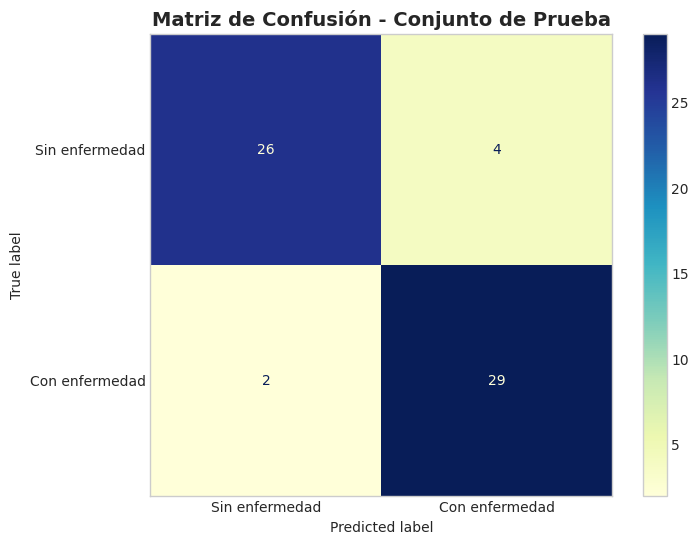


📋 REPORTE DE CLASIFICACIÓN DETALLADO:
                precision    recall  f1-score   support

Sin enfermedad     0.9286    0.8667    0.8966        30
Con enfermedad     0.8788    0.9355    0.9062        31

      accuracy                         0.9016        61
     macro avg     0.9037    0.9011    0.9014        61
  weighted avg     0.9033    0.9016    0.9015        61


💡 TODO: [generaliza bien si las metricas en test son son similares a las obtenidas en validacion cruzada sobre train. una caida grande indicaria overfitting] ¿El modelo generaliza bien? ¿Cómo lo sabes?


In [0]:
# TODO: [Estos resultados en test son la evaluacon mas honesta del modelo, ya que usa datos que nunca vio ni durante el netrenamiento ni la validacion cruzada, simulando como se comportaria con pacietnes nuevos] ¿Qué significan estos resultados en el conjunto de prueba?
print("=" * 70)
print("🎉 RESULTADOS FINALES EN CONJUNTO DE PRUEBA")
print("=" * 70)

final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

print(f"🎯 Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"🎯 Precision: {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"❤️  Recall: {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"⚖️  F1 Score: {final_f1:.4f}")
print(f"📈 ROC-AUC: {final_roc_auc:.4f}")
print("=" * 70)

# Matriz de confusión final
print("\n📊 Matriz de Confusión Final:\n")
cm_final = confusion_matrix(y_test, final_preds)
disp_final = ConfusionMatrixDisplay(cm_final, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_final.plot(ax=ax, cmap='YlGnBu')
plt.title('Matriz de Confusión - Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

# Reporte de clasificación completo
print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print("=" * 70)
print(classification_report(y_test, final_preds, 
                          target_names=['Sin enfermedad', 'Con enfermedad'],
                          digits=4))
print("=" * 70)

print("\n💡 TODO: [generaliza bien si las metricas en test son son similares a las obtenidas en validacion cruzada sobre train. una caida grande indicaria overfitting] ¿El modelo generaliza bien? ¿Cómo lo sabes?")

## 🎉 ¡Proyecto Completado!

### ✅ Lo que Hemos Logrado

1. ✅ **Explorado datos médicos reales** con análisis visual
2. ✅ **Construido un pipeline completo** de preprocesamiento
3. ✅ **Entrenado y comparado** 2 modelos (SGD y Random Forest)
4. ✅ **Evaluado con múltiples métricas** de clasificación
5. ✅ **Usado validación cruzada** para validación robusta
6. ✅ **Registrado experimentos** en MLflow
7. ✅ **Interpretado resultados** con matrices de confusión

### 📊 Conclusiones Clave

**TODO: [Completa aquí] Basándote en todos los resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - [Random Forest funcionó mejor en general, ya que obtuvo mejores valores de precision, F1 y ROC-AUC. En test alcanzó además un recall del 93,55 %.]

2. **¿Por qué crees que funcionó mejor?**
   - [Porque Random Forest puede aprender relaciones más complejas entre las variables, mientras que SGD utiliza un modelo más simple y lineal.]

3. **¿El modelo es suficientemente bueno para uso médico?**
   - [Los resultados son buenos, con un accuracy del 90,16 % y un recall del 93,55 %, pero no sería suficiente para utilizarlo por sí solo en un entorno médico. Debería validarse con más pacientes y utilizarse como apoyo a los profesionales.]

4. **¿Qué métrica es más importante en este caso?**
   - [El recall, porque interesa detectar al mayor número posible de pacientes que realmente tienen la enfermedad y evitar falsos negativos.]

5. **¿Qué mejorarías del modelo?**
   - [Probaría a ajustar mejor los hiperparámetros de Random Forest, utilizar más datos y comparar con otros modelos para intentar reducir todavía más los falsos negativos.]

---

### 🎓 Conceptos Aprendidos

#### 📚 Machine Learning
- Clasificación binaria
- Validación cruzada
- Train/test split
- Overfitting vs generalización

#### 🔧 Preprocesamiento
- Normalización (StandardScaler)
- One-Hot Encoding
- Imputación de valores nulos
- Pipelines de transformación

#### 📊 Evaluación
- Accuracy, Precision, Recall, F1
- Matriz de confusión
- ROC-AUC
- Trade-offs entre métricas

#### 🤖 Modelos
- SGD Classifier
- Random Forest
- Comparación de modelos
- Selección de modelo

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina y IA

**TODO: [Completa aquí] Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - [En este caso, los falsos negativos son más graves porque significan que el modelo clasifica como sano a un paciente que realmente tiene la enfermedad. Esto podría retrasar el diagnóstico y el tratamiento.]

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - [No, un modelo de IA no debería tomar decisiones médicas por sí solo. Puede servir como herramienta de apoyo, pero la decisión final debería tomarla un profesional sanitario teniendo en cuenta toda la información del paciente.]

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - [Es importante que los médicos entiendan cómo decide el modelo para poder confiar en sus resultados y comprobar si las predicciones tienen sentido. Además, ayuda a detectar posibles errores o decisiones poco fiables del modelo.]

---

### 🚀 Próximos Pasos

#### 🎯 Desafíos Adicionales

1. **Optimización de Hiperparámetros**
   ```python
   # TODO: Implementa GridSearchCV
   from sklearn.model_selection import GridSearchCV
   param_grid = {
       'n_estimators': [50, 100, 200],
       'max_depth': [5, 10, 15, None],
       'min_samples_split': [2, 5, 10]
   }
   ```

2. **Prueba Otros Modelos**
   - Gradient Boosting
   - XGBoost
   - SVM
   - Neural Networks

3. **Feature Engineering**
   - Crea nuevas características
   - Analiza importancia de características
   - Selecciona las más relevantes

4. **Análisis de Errores**
   - ¿Qué pacientes se clasifican mal?
   - ¿Hay patrones en los errores?
   - ¿Cómo mejorar?

5. **Curva ROC**
   - Implementa y visualiza la curva ROC
   - Encuentra el threshold óptimo
   - Compara AUC de diferentes modelos

---

### 📖 Recursos para Seguir Aprendiendo

- **Scikit-learn**: [Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)
- **MLflow**: [Tracking Documentation](https://mlflow.org/docs/latest/tracking.html)
- **Kaggle**: Notebooks sobre Heart Disease
- **Papers**: Sobre IA en diagnóstico médico

---

### 🌟 ¡Felicidades!

Has completado un proyecto completo de Machine Learning en el dominio médico. Las habilidades que has desarrollado son aplicables a muchos otros problemas de clasificación.

**Puntos clave para recordar:**
- ✅ Siempre explora tus datos primero
- ✅ Usa validación cruzada para evaluar
- ✅ Compara múltiples modelos
- ✅ Elige métricas según el problema
- ✅ En medicina, prioriza recall sobre precision
- ✅ Documenta todo con MLflow
- ✅ Piensa en las implicaciones éticas

**¡Sigue practicando y construyendo proyectos! 🚀❤️**

In [0]:
# Preparar datos de test
x_test = test_set.drop("target", axis=1)
y_test = test_set.target

# Aplicar el pipeline al test
x_test_pr = full_pipeline.transform(x_test)

# Entrenar Random Forest final
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_train_pr, y_train)

# Predicciones finales
final_preds = forest_clf.predict(x_test_pr)

print("Datos preparados correctamente")
print("x_train_pr:", x_train_pr.shape)
print("x_test_pr:", x_test_pr.shape)

2026/10/03 17:57:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o936.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

Datos preparados correctamente
x_train_pr: (242, 23)
x_test_pr: (61, 23)


2026/10/03 17:57:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o998.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

Mejores parámetros:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}

Mejor recall:
0.8584045584045583


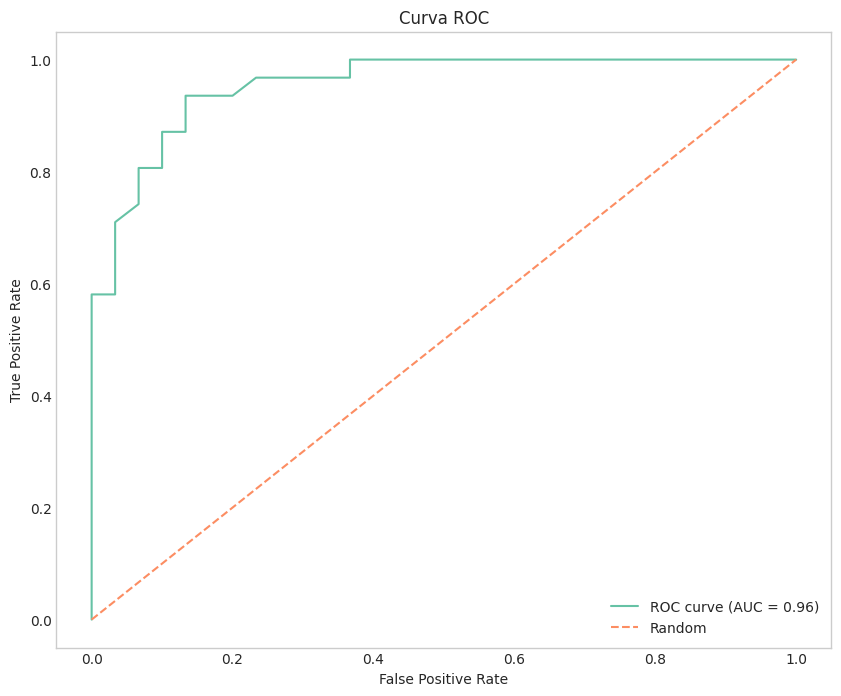

AUC: 0.9559139784946236
                feature  importance
3               thalach    0.117086
5                    ca    0.106650
6                  thal    0.090651
4               oldpeak    0.088282
2                  chol    0.077403
12    cp_typical angina    0.074709
1              trestbps    0.068765
0                   age    0.067796
18             exang_No    0.044424
19            exang_Yes    0.041902
20    slope_downsloping    0.037070
7            sex_Female    0.029922
8              sex_Male    0.028799
21           slope_flat    0.020782
11  cp_non-anginal pain    0.019131


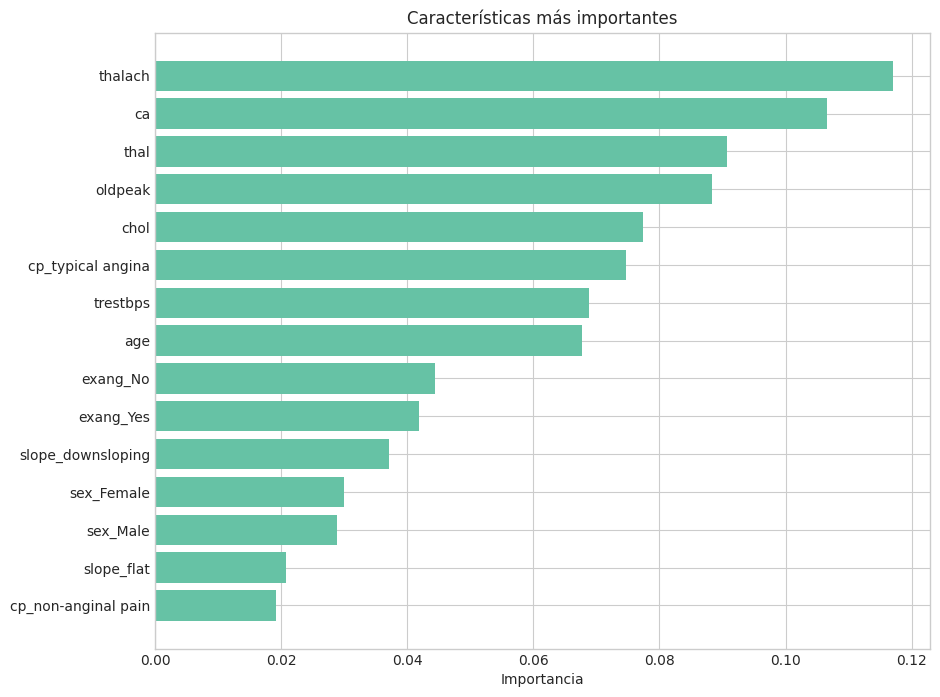

2026/10/03 17:58:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o1074.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

                Modelo  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.918033   0.906250  0.935484  0.920635
1                  SVM  0.885246   0.875000  0.903226  0.888889
2    Gradient Boosting  0.852459   0.866667  0.838710  0.852459
Total de errores: 6

Pacientes mal clasificados:
     age     sex                cp  trestbps   chol  target  prediccion
302   57  Female   atypical angina     130.0  236.0       0           1
272   67    Male    typical angina     120.0  237.0       0           1
42    45    Male    typical angina     104.0  208.0       1           0
95    53    Male    typical angina     142.0    NaN       1           0
259   38    Male      asymptomatic     120.0  231.0       0           1
196   46    Male  non-anginal pain     150.0  231.0       0           1

Características de los pacientes mal clasificados:
             age    trestbps       chol  ...      thal    target  prediccion
count   6.000000    6.000000    5.00000  ...  6.000000  6.0000

In [0]:
# 🎨 CÓDIGO DE EJEMPLO PARA LOS DESAFÍOS
# Descomenta y completa para explorar más

# ========================================
# DESAFÍO 1: Grid Search
# ========================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(x_train_pr, y_train)

print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor recall:")
print(grid_search.best_score_)


# ========================================
# DESAFÍO 2: Curva ROC
# ========================================

from sklearn.metrics import roc_curve, auc

y_proba = forest_clf.predict_proba(x_test_pr)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(10, 8))

plt.plot(
    fpr,
    tpr,
    label=f'ROC curve (AUC = {roc_auc_curve:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid()

plt.show()

print("AUC:", roc_auc_curve)


# ========================================
# DESAFÍO 3: Importancia de Características
# ========================================

feature_names = (
    num_attr +
    list(
        full_pipeline
        .named_transformers_['cat']
        .get_feature_names_out(cat_attr)
    )
)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': forest_clf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

print(feature_importance.head(15))

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance.head(15)['feature'],
    feature_importance.head(15)['importance']
)

plt.xlabel('Importancia')
plt.title('Características más importantes')

plt.gca().invert_yaxis()

plt.show()


# ========================================
# DESAFÍO 4: Comparar Más Modelos
# ========================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

modelos = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

resultados = []

for nombre, modelo in modelos.items():

    modelo.fit(x_train_pr, y_train)

    preds_modelo = modelo.predict(x_test_pr)

    acc = accuracy_score(y_test, preds_modelo)
    prec = precision_score(y_test, preds_modelo)
    rec = recall_score(y_test, preds_modelo)
    f1_s = f1_score(y_test, preds_modelo)

    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1_s
    })

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    'Recall',
    ascending=False
)

print(df_resultados)


# ========================================
# DESAFÍO 5: Análisis de Errores
# ========================================

errors_mask = final_preds != y_test.to_numpy()

errors_df = test_set.iloc[
    np.where(errors_mask)[0]
].copy()

errors_df['prediccion'] = final_preds[errors_mask]

print("Total de errores:", len(errors_df))

print("\nPacientes mal clasificados:")

print(
    errors_df[
        [
            'age',
            'sex',
            'cp',
            'trestbps',
            'chol',
            'target',
            'prediccion'
        ]
    ]
)

print("\nCaracterísticas de los pacientes mal clasificados:")

print(errors_df.describe())

print("\n💡 Desafíos completados")